# 08 — Breakout board: every season's top candidates

For each season from 2014-15 to 2025-26, the **boosted-trees model** (the backtest winner, D19) ranks every player aged ≤ 25 by his chance of breaking out the *following* season, using only seasons whose outcomes were already known. This notebook turns those rankings into:

1. a **poster** (`outputs/figures/08_breakout_board.png`): one panel per season, top 10, coloured by what actually happened;
2. an **interactive page** (`outputs/breakout_board.html`): open it in a browser, click a season, switch between top 10 and top 25.

Both are local files; nothing is published.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.backtest import boosted_trees, feature_columns, walk_forward
from unicorn.board import build_board, render_html, season_summary
from unicorn.labels import add_future, add_labels, add_star_score
from unicorn.plotting import apply_style, BLUE, INK, INK2, MUTED, FIG_DIR, SURFACE
from unicorn.raw import PROJECT_ROOT

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
uni = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet")
lab = add_future(add_star_score(add_labels(uni)), ["breakout_any"], horizon=1)
FEATURES = feature_columns(lab)

# 2014-15 is the first season with enough earlier outcomes to learn from; 2025-26 is the live season
preds = walk_forward(lab, "breakout_any_next1", 1, lab["age"] <= 25, 2014, 2025, {"boosted trees": boosted_trees}, FEATURES)
board = build_board(lab, preds, top_n=25)
summary = season_summary(board, preds)
summary.round(3)

,test_season,season_label,outcome_label,pending,pool,hits_top10,base_rate,expected_top10_by_chance
0,2014,2014-15,2015-16,False,186,5,0.081,0.806
1,2015,2015-16,2016-17,False,179,4,0.089,0.894
2,2016,2016-17,2017-18,False,192,6,0.130,1.302
3,2017,2017-18,2018-19,False,224,4,0.089,0.893
4,2018,2018-19,2019-20,False,229,5,0.083,0.830
5,2019,2019-20,2020-21,False,252,4,0.075,0.754
6,2020,2020-21,2021-22,False,254,3,0.067,0.669
7,2021,2021-22,2022-23,False,287,3,0.035,0.348
8,2022,2022-23,2023-24,False,248,4,0.040,0.403
9,2023,2023-24,2024-25,False,266,0,0.038,0.376


## Poster

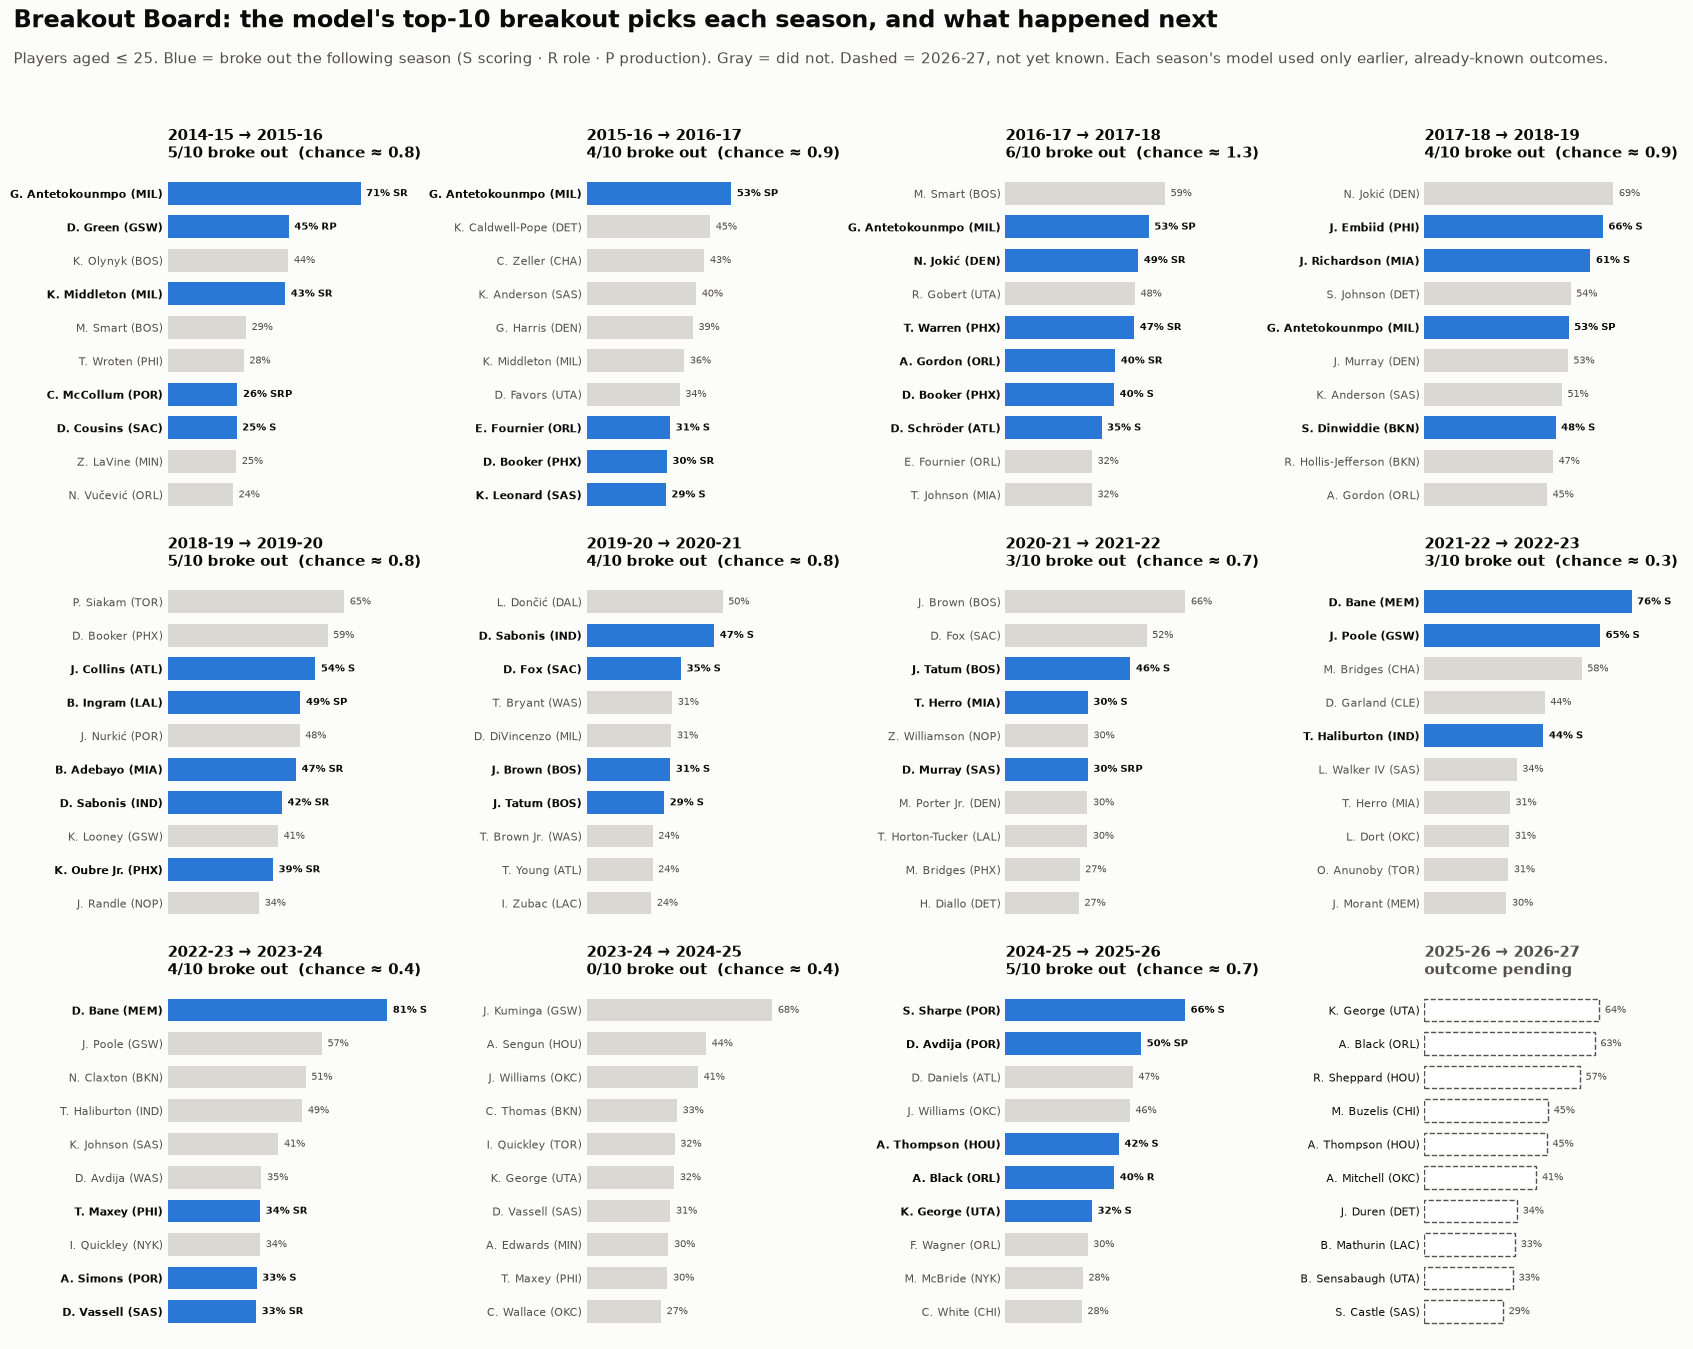

In [2]:
seasons = summary["test_season"].tolist()

def short(name):
    parts = name.split()
    return f"{parts[0][0]}. {' '.join(parts[1:])}" if len(parts) > 1 else name
fig, axes = plt.subplots(3, 4, figsize=(17, 13.5))
for ax, s in zip(axes.flat, seasons):
    g = board[(board["test_season"] == s) & (board["rank"] <= 10)].iloc[::-1]
    info = summary.set_index("test_season").loc[s]
    pending = info["pending"]
    colors = [BLUE if st == "hit" else ("#ffffff" if st == "pending" else "#d9d8d2") for st in g["status"]]
    ax.barh(range(len(g)), g["score"], color=colors, height=0.68,
            edgecolor=[INK2 if st == "pending" else "none" for st in g["status"]], linewidth=1, linestyle="--")
    for y, (_, r) in enumerate(g.iterrows()):
        tag = {"scoring": "S", "role": "R", "production": "P"}
        types = "".join(tag[t] for t in r["breakout_types"].split(", ") if t) if r["status"] == "hit" else ""
        ax.annotate(f"{r['score']:.0%} {types}".strip(), (r["score"], y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=7.5, color=INK if r["status"] == "hit" else INK2,
                    fontweight="bold" if r["status"] == "hit" else "normal")
    ax.set_yticks(range(len(g)), [f"{short(r['player_name'])} ({r['team_abbreviation']})" for _, r in g.iterrows()], fontsize=8)
    for lbl, st in zip(ax.get_yticklabels(), g["status"]):
        lbl.set_color(INK if st != "miss" else INK2)
        lbl.set_fontweight("bold" if st == "hit" else "normal")
    ax.set_xlim(0, 0.95); ax.set_xticks([]); ax.grid(False)
    ax.spines["bottom"].set_visible(False); ax.spines["left"].set_visible(False); ax.tick_params(axis="y", length=0)
    headline = "outcome pending" if pending else f"{int(info['hits_top10'])}/10 broke out  (chance ≈ {info['expected_top10_by_chance']:.1f})"
    ax.set_title(f"{info['season_label']} → {info['outcome_label']}\n{headline}", loc="left", fontsize=10.5,
                 color=INK if not pending else INK2)
fig.suptitle("Breakout Board: the model's top-10 breakout picks each season, and what happened next",
             x=0.01, ha="left", fontsize=17, fontweight="bold", y=0.995)
fig.text(0.01, 0.955, "Players aged ≤ 25. Blue = broke out the following season (S scoring · R role · P production). Gray = did not. "
         "Dashed = 2026-27, not yet known. Each season's model used only earlier, already-known outcomes.",
         ha="left", fontsize=10.5, color=INK2)
fig.tight_layout(rect=(0, 0, 1, 0.945))
fig.subplots_adjust(wspace=0.62)
fig.savefig(FIG_DIR / "08_breakout_board.png", dpi=150, bbox_inches="tight")

## Interactive page

In [3]:
html_path = render_html(board, summary, PROJECT_ROOT / "outputs" / "breakout_board.html")
board.to_csv(PROJECT_ROOT / "outputs" / "tables" / "08_breakout_board.csv", index=False)
print("open in a browser:", html_path.relative_to(PROJECT_ROOT))

open in a browser: outputs/breakout_board.html


## Findings

- **Every backtest season but one beats chance by a wide margin.** The top 10 contains 3–6 eventual breakouts per season, where chance would give about 0.4–1.3.
- **2023-24 → 2024-25 is the exception: 0 of 10** (Kuminga, Şengün, Jalen Williams, Cam Thomas, Quickley…). Several of them had good seasons that didn't meet the breakout bar, but it's a genuine miss and a reminder that this is a probabilistic ranking.
- The live 2025-26 → 2026-27 board (Keyonte George, Anthony Black, Reed Sheppard, Matas Buzelis, Amen Thompson…) can be scored at the end of 2026-27.